# Exploratory Data Analysis (EDA) & Data Cleaning

This notebook performs a deep dive into the provided image dataset to identify and resolve issues such as class imbalance, data leakage, and duplicate images with conflicting labels.

In [16]:
import os
import hashlib
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Helper Functions for Metadata Extraction

In [17]:
def get_image_info(img_path):
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode
            format = img.format
            return width, height, mode, format
    except Exception as e:
        return None, None, None, str(e)

def calculate_hash(img_path):
    hash_md5 = hashlib.md5()
    with open(img_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

def scan_dataset(data_dir):
    data = []
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        files = os.listdir(cls_path)
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp')):
                img_path = os.path.join(cls_path, f)
                w, h, m, fmt = get_image_info(img_path)
                md5 = calculate_hash(img_path)
                data.append({
                    'split': os.path.basename(data_dir),
                    'class': cls,
                    'filename': f,
                    'path': img_path,
                    'width': w,
                    'height': h,
                    'aspect_ratio': round(w / h, 2) if h and h > 0 else 0,
                    'mode': m,
                    'format': fmt,
                    'md5': md5,
                    'size_kb': os.path.getsize(img_path) / 1024
                })
    return pd.DataFrame(data)

## 2. Scanning the Dataset

In [18]:
train_df = scan_dataset('data_train')
test_df = scan_dataset('data_test')
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Total images found: {len(df)}")
display(df.head())

Total images found: 320


,split,class,filename,path,width,height,aspect_ratio,mode,format,md5,size_kb
0,data_train,em_bé_chơi_verified,0020_d10406b35ffc.jpg,data_train/em_bé_chơi_verified/0020_d10406b3...,626,416,1.50,RGB,JPEG,d10406b35ffcb8fd51502150320607bc,100.515625
1,data_train,em_bé_chơi_verified,0033_dc8d732281ba.jpg,data_train/em_bé_chơi_verified/0033_dc8d7322...,1200,628,1.91,RGB,JPEG,dc8d732281ba5c593e327b4145e07305,126.458008
2,data_train,em_bé_chơi_verified,0016_2d56040e719c.jpg,data_train/em_bé_chơi_verified/0016_2d56040e...,1000,667,1.50,RGB,JPEG,2d56040e719ce405da3e88467dd457a5,92.551758
3,data_train,em_bé_chơi_verified,0044_9f0099b723af.jpg,data_train/em_bé_chơi_verified/0044_9f0099b7...,1280,720,1.78,RGB,JPEG,9f0099b723af39a52b71490c0da91189,119.230469
4,data_train,em_bé_chơi_verified,0030_c96cf87c1d08.webp,data_train/em_bé_chơi_verified/0030_c96cf87c...,399,208,1.92,RGB,WEBP,c96cf87c1d0899ba7e47525758130321,126.550781


## 3. Class Distribution and Data Split

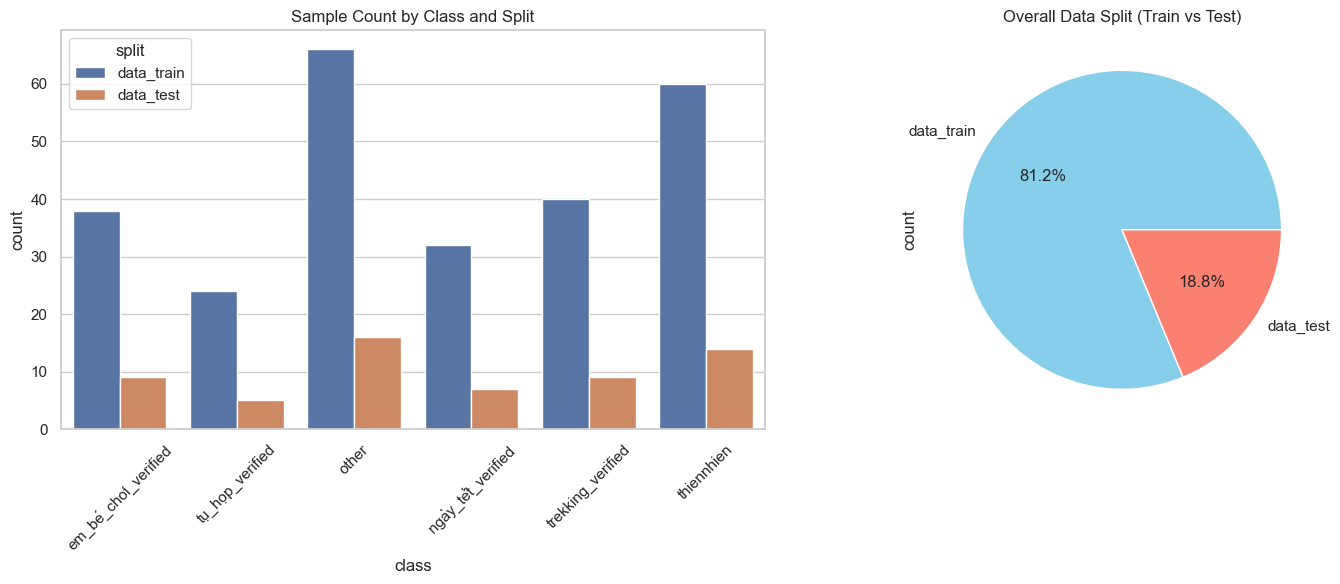

In [19]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='class', hue='split')
plt.title('Sample Count by Class and Split')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['split'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Overall Data Split (Train vs Test)')

plt.tight_layout()
plt.show()

## 4. Visualizing Image Size Issues

Images for classification are usually resized or padded to a fixed size (e.g., 224x224). If aspect ratios vary significantly, simple resizing might distort the images, or padding might introduce a lot of black/white borders.

Text(0.5, 0, 'Aspect Ratio (Width / Height)')

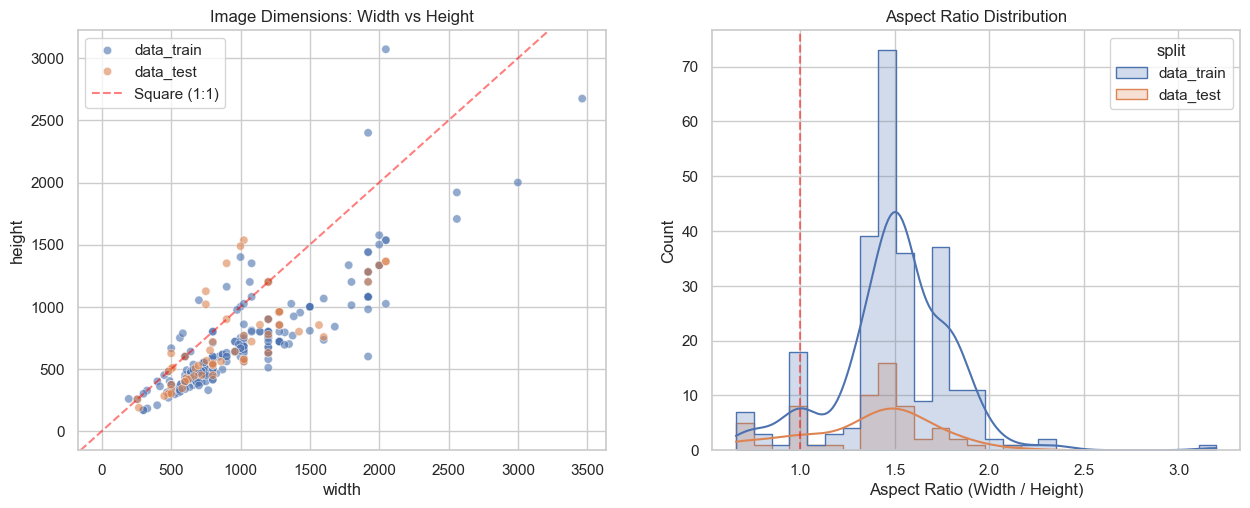

In [21]:
plt.figure(figsize=(15, 12))

# 4.1 Scatter plot of Dimensions
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='width', y='height', hue='split', alpha=0.6)
plt.axline((0, 0), slope=1, color='red', linestyle='--', alpha=0.5, label='Square (1:1)')
plt.title('Image Dimensions: Width vs Height')
plt.legend()

# 4.2 Aspect Ratio Distribution
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='aspect_ratio', hue='split', kde=True, element='step')
plt.axvline(1.0, color='red', linestyle='--', alpha=0.5)
plt.title('Aspect Ratio Distribution')
plt.xlabel('Aspect Ratio (Width / Height)')

# # 4.3 Aspect Ratio by Class
# plt.subplot(2, 1, 2)
# sns.boxplot(data=df, x='class', y='aspect_ratio', hue='split')
# plt.axhline(1.0, color='red', linestyle='--', alpha=0.5)
# plt.title('Aspect Ratio Variation by Class')
# plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()

# print("Descriptive Statistics for Dimensions:")
# display(df[['width', 'height', 'aspect_ratio']].describe())

## 5. Metadata Quality: Duplicates & Leakage

In [ ]:
# Exact Duplicates in Training set
train_dupes = train_df[train_df.duplicated('md5', keep=False)].sort_values('md5')
print(f"Found {len(train_dupes)} training images involved in duplicates.")

# Data Leakage (Train vs Test)
leakage = train_df[train_df['md5'].isin(test_df['md5'])]
print(f"\nWARNING: Found {len(leakage)} images from training set present in test set (Data Leakage)!")

## 6. Advanced Quality Checks: Test Set & Specific Duplicates

We now check for duplicates within the test set and identify specific multi-folder and intra-class duplicates in the training set.

In [ ]:
# 6.1 Check for duplicates within the Test set
test_dupes = test_df[test_df.duplicated('md5', keep=False)].sort_values('md5')
print(f"Found {len(test_dupes)} duplicate images within the test set.")
if not test_dupes.empty:
    display(test_dupes[['class', 'filename', 'md5']])

# 6.2 Intra-class duplicates (same image multiple times in same folder)
intra_class_dupes = train_df[train_df.duplicated(['class', 'md5'], keep=False)]
print(f"\nFound {len(intra_class_dupes)} instances of intra-class duplicates in training set.")
if not intra_class_dupes.empty:
    display(intra_class_dupes.sort_values(['class', 'md5'])[['class', 'filename', 'md5']])

## 7. Label Conflict Resolution Logic

Identify images that appear in multiple folders. 
**Rule:** If an image is in `other` AND a specific class (e.g. `ngày_tết_verified`), we mark the `other` version for deletion to prioritize the specific label.

In [ ]:
to_delete_from_train = []

# A. Resolve Leakage: Remove images from Train that exist in Test
leakage_train_paths = train_df[train_df['md5'].isin(test_df['md5'])]['path'].tolist()
to_delete_from_train.extend(leakage_train_paths)
print(f"Marked {len(leakage_train_paths)} leaked images for removal from training set.")

# B. Resolve Other vs Specific conflicts in Training Set
all_train_dupes = train_df[train_df.duplicated('md5', keep=False)]
for md5, group in all_train_dupes.groupby('md5'):
    classes = group['class'].unique()
    if len(classes) > 1:
        if 'other' in classes:
            # Mark 'other' paths for deletion
            other_paths = group[group['class'] == 'other']['path'].tolist()
            to_delete_from_train.extend(other_paths)
            print(f"Conflict for {md5}: Found in 'other' and {[c for c in classes if c != 'other']}. Marked 'other' for deletion.")
        else:
            print(f"Manual Review Required: {md5} exists in multiple specific classes: {classes.tolist()}")

# C. Handle Intra-class duplicates (keep only one version per class)
for (cls, md5), group in train_df.groupby(['class', 'md5']):
    if len(group) > 1:
        extra_paths = group.iloc[1:]['path'].tolist()
        to_delete_from_train.extend(extra_paths)
        print(f"Intra-class duplicate in {cls}: marking extra instances of {md5} for deletion.")

to_delete_from_train = list(set(to_delete_from_train))
print(f"\nTotal files unique for deletion in training set: {len(to_delete_from_train)}")

## 8. Data Cleaning Preview & Script

In [ ]:
print("Files to be deleted from data_train:")
for p in sorted(to_delete_from_train):
    print(f" - {p}")

## 9. Visual Exploration: Sample Grids

In [ ]:
def plot_sample_grid(dataframe, n_samples=3):
    classes = dataframe['class'].unique()
    fig, axes = plt.subplots(len(classes), n_samples, figsize=(15, 3 * len(classes)))
    
    for i, cls in enumerate(classes):
        cls_samples = dataframe[dataframe['class'] == cls].sample(min(n_samples, len(dataframe[dataframe['class'] == cls])))
        for j, (_, row) in enumerate(cls_samples.iterrows()):
            img = Image.open(row['path'])
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(f"{cls}\n{row['width']}x{row['height']}", fontsize=9)
            ax.axis('off')
        
        for j in range(len(cls_samples), n_samples):
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.axis('off')
    plt.tight_layout()
    plt.show()

print("Representative Samples from Training Set:")
plot_sample_grid(train_df, n_samples=4)

## 10. Summary & Recommendations

1. **Image Size Disparity**: The scatter and aspect ratio plots (Section 4) show a wide variety of dimensions. Consider using `Letterbox` padding during training to avoid distortion.
2. **Data Leakage**: Section 7 identifies specific training files that are identical to test files and must be removed.
3. **Cleaning Strategy**: Execute the logic in Section 7 to resolve all duplicate and label conflict issues.